In [48]:
import torch
import torch.nn as nn
from torch.nn import functional as F

block_size = 256
n_embd = 512
n_head = 8
n_layer = 6
dropout = 0.0
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [49]:

checkpoint = torch.load('../model/bible_best.pt', map_location=device, weights_only=False)
stoi = checkpoint['stoi']
itos = checkpoint['itos']
vocab_size = checkpoint['vocab_size']
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l])


In [50]:

class MaskedSelfAttention(nn.Module):
    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.dropout = nn.Dropout(dropout)
        self.cache_k = None
        self.cache_v = None
        self.use_kv_cache = False

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)
        q = self.query(x)
        v = self.value(x)

        if self.use_kv_cache:
            if self.cache_k is not None:
                k = torch.cat([self.cache_k, k], dim=1)
                v = torch.cat([self.cache_v, v], dim=1)
            self.cache_k = k
            self.cache_v = v

        # build explicit causal mask when Q and K lengths differ
        q_len = q.shape[1]
        k_len = k.shape[1]

        if q_len == k_len:
            # training or no-cache inference — use fast path
            out = F.scaled_dot_product_attention(q, k, v,
                  attn_mask=None,
                  dropout_p=dropout if self.training else 0.0,
                  is_causal=True)
        else:
            # decode step — Q is 1 token, K/V are full sequence
            # every key position is visible to the query (it's already causal by construction)
            out = F.scaled_dot_product_attention(q, k, v,
                  attn_mask=None,
                  dropout_p=0.0,
                  is_causal=False)  # no mask needed — single query attends to all past

        return out

    def clear_cache(self):
        self.cache_k = None
        self.cache_v = None


In [51]:

class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([MaskedSelfAttention(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        return self.dropout(self.proj(out))


class FeedForward(nn.Module):
    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.GELU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class Block(nn.Module):
    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedForward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x


In [52]:

class GPTLanguageModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head=n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def _all_heads(self):
        for block in self.blocks:
            for head in block.sa.heads:
                yield head

    def enable_kv_cache(self):
        for head in self._all_heads():
            head.use_kv_cache = True
            head.clear_cache()

    def disable_kv_cache(self):
        for head in self._all_heads():
            head.use_kv_cache = False
            head.clear_cache()

    def forward(self, idx, targets=None, pos=None):
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx)
        if pos is not None:
            pos_emb = self.position_embedding_table(pos)
        else:
            pos_emb = self.position_embedding_table(torch.arange(T, device=device))
        x = self.blocks(tok_emb + pos_emb)
        x = self.ln_f(x)
        logits = self.lm_head(x)
        loss = None
        if targets is not None:
            B, T, C = logits.shape
            loss = F.cross_entropy(logits.view(B*T, C), targets.view(B*T))
        return logits, loss

    def generate(self, idx, max_new_tokens, temperature=0.8, use_kv_cache=False):
        if use_kv_cache:
            self.enable_kv_cache()
            prompt_len = idx.shape[1]
            pos = torch.arange(prompt_len, device=device)
            _, _ = self(idx, pos=pos)
            current_pos = prompt_len
            print(f"prompt_len={prompt_len}, first decode pos will be={current_pos}")

        for _ in range(max_new_tokens):
            if use_kv_cache:
                idx_cond = idx[:, -1:]
                pos = torch.tensor([current_pos % block_size], device=device)
                current_pos += 1 
            else:
                idx_cond = idx[:, -block_size:]
                pos = None

            logits, _ = self(idx_cond, pos=pos)
            logits = logits[:, -1, :] / temperature
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)

        if use_kv_cache:
            self.disable_kv_cache()

        return idx


In [53]:

# ── Load model ─────────────────────────────────────────────────────────────
model = GPTLanguageModel().to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

GPTLanguageModel(
  (token_embedding_table): Embedding(84, 512)
  (position_embedding_table): Embedding(256, 512)
  (blocks): Sequential(
    (0): Block(
      (sa): MultiHeadAttention(
        (heads): ModuleList(
          (0-7): 8 x MaskedSelfAttention(
            (key): Linear(in_features=512, out_features=64, bias=False)
            (query): Linear(in_features=512, out_features=64, bias=False)
            (value): Linear(in_features=512, out_features=64, bias=False)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (proj): Linear(in_features=512, out_features=512, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ffwd): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=512, out_features=2048, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=2048, out_features=512, bias=True)
          (3): Dropout(p=0.0, inplace=False)
        )
      )
      (ln1): LayerNorm((512

In [54]:

# ── Inference ──────────────────────────────────────────────────────────────
prompt = 'In the beginning'

In [55]:

# without KV cache
output_no_cache = decode(
    model.generate(
        torch.tensor([encode(prompt)], dtype=torch.long, device=device),
        max_new_tokens=100,
        use_kv_cache=False
    )[0].tolist()
)

In [56]:

# with KV cache
output_kv_cache = decode(
    model.generate(
        torch.tensor([encode(prompt)], dtype=torch.long, device=device),
        max_new_tokens=100,
        use_kv_cache=True
    )[0].tolist()
)

print("=== Without KV Cache ===")
print(output_no_cache)
print("\n=== With KV Cache ===")
print(output_kv_cache)

prompt_len=16, first decode pos will be=16
=== Without KV Cache ===
In the beginning of the LORD: and the
mighty branch shall say: What the LORD is the blood of the LORD is
my God? 22:

=== With KV Cache ===
In the beginning of Peter? and have seen the firstfruits? and
what man have not deceived all that they are not to th


In [61]:
print(decode(
    model.generate(
        torch.tensor([encode("lord of the ring of ")], dtype=torch.long, device=device),
        max_new_tokens=180,
        use_kv_cache=True
    )[0].tolist()
))

prompt_len=20, first decode pos will be=20
lord of the ring of Israel.

14:28. And he answered: If there be no more doing among them: but he
that hath a parce in the wilderness of Israel, and a certain man of
wise man hath brought my mouth rig


In [64]:
import matplotlib.pyplot as plt

def plot_training_loss(train_steps, train_losses, val_steps, val_losses):
    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(train_steps, train_losses, label='Train loss', color='#378ADD', linewidth=2)
    ax.plot(val_steps, val_losses, label='Val loss', color='#D85A30', linewidth=2, linestyle='--')

    ax.set_xlabel('Step')
    ax.set_ylabel('Loss')
    ax.set_title('Training and Validation Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('.assets/training_loss1.jpg', dpi=150, bbox_inches='tight')
    plt.show()

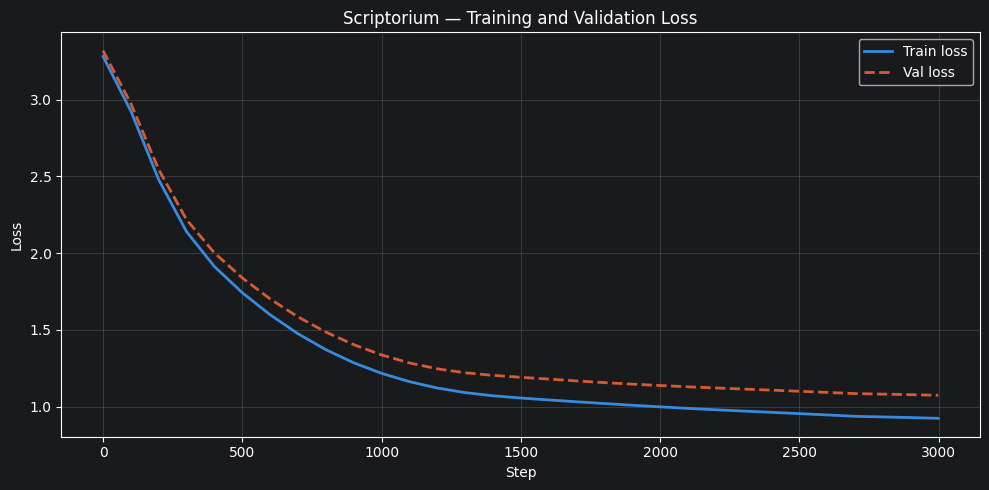

In [69]:
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

def plot_training_loss():
    steps = [0, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400,
             1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300, 2400, 2500, 2600, 2700, 2900, 2999]

    train_losses = [4.34, 2.38, 2.25, 2.07, 1.88, 1.72, 1.58, 1.45, 1.35, 1.27, 1.20,
                    1.15, 1.11, 1.08, 1.06, 1.0617, 1.0449, 1.0293, 1.0216, 1.0100,
                    0.9989, 0.9881, 0.9788, 0.9729, 0.9637, 0.9549, 0.9473, 0.9426, 0.9221, 0.9182]

    val_losses   = [4.34, 2.45, 2.32, 2.15, 1.97, 1.82, 1.68, 1.56, 1.47, 1.39, 1.32,
                    1.27, 1.23, 1.21, 1.20, 1.1957, 1.1802, 1.1686, 1.1534, 1.1457,
                    1.1412, 1.1257, 1.1218, 1.1172, 1.1084, 1.0993, 1.0953, 1.0889, 1.0711, 1.0703]

    train_smooth = gaussian_filter1d(train_losses, sigma=1.5)
    val_smooth   = gaussian_filter1d(val_losses,   sigma=1.5)

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(steps, train_smooth, label='Train loss', color='#378ADD', linewidth=2)
    ax.plot(steps, val_smooth,   label='Val loss',   color='#D85A30', linewidth=2, linestyle='--')

    ax.set_xlabel('Step')
    ax.set_ylabel('Loss')
    ax.set_title('Scriptorium — Training and Validation Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('../assets/training_loss.jpg', dpi=150, bbox_inches='tight')
    plt.show()

plot_training_loss()